# Supply Chain Performance & Operations Analytics Dashboard

---

## Phase 2 — Data Cleaning & Feature Engineering
In Phase 1 we explored the raw data and documented every issue. This notebook fixes them and goes further by engineering new columns that don't exist in the raw data but are essential for Power BI analysis.

## Critical Context — Dataset Grain

> Each row in this dataset is **one order item, not one order**.  
> One order containing 3 products creates **3 rows with the same `Order Id`**.  
> All order-level KPIs must account for this using:
>
> - `groupby('Order Id')` in Python
> - `DISTINCTCOUNT` in Power BI

---

## What This Notebook Does

| Step | Task |
|---|---|
| 1 | Import libraries and set up file paths |
| 2 | Reload raw data from original CSV |
| 3 | Convert date columns from text → datetime |
| 4 | Handle missing values strategically |
| 5 | Engineer 8 new analytical columns |
| 6 | Drop irrelevant and personal data columns |
| 7 | Build star schema — split into 5 structured tables |
| 8 | Export order-level summary table |
| 9 | Validate all exports before Phase 3 |

---

### Carrying forward from Phase 1

- 180,516 rows × 53 columns (180,519 raw − 3 dropped for missing Customer Zipcode)
- 65,749 unique orders (dataset is at order-item level)
- 336,209 missing cells across 4 columns
- 0 duplicate rows
- 2 date columns stored as text
- 54.8% late delivery risk rate

# Import Libraries

In [1]:
# Standard libraries 
import pandas as pd          # DataFrames — tabular data manipulation
import numpy as np           # Numerical operations and array handling
import os                    # File system — folder creation and path joining
import warnings
warnings.filterwarnings('ignore')   # Suppress non-critical version warnings

# Visualisation 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# Display settings 
pd.set_option('display.max_columns', None)       # Never truncate columns
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

# File paths 
BASE_PATH   = r'C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard'
MAIN_DATA   = BASE_PATH + r'\DataCoSupplyChainDataset.csv'   # Raw source file
OUTPUT_PATH = BASE_PATH + r'\data\processed'                  # Export destination

# Create output folder if it doesn't already exist 
# exist_ok=True prevents crash if the folder was already created
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Setup complete.")
print(f"Output folder: {OUTPUT_PATH}")

Setup complete.
Output folder: C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard\data\processed


# Load The Dataset
Why `encoding='latin-1'`?
The DataCo CSV uses Latin-1 encoding (ISO-8859-1) which handles special characters in city names like São Paulo. Without this, Python throws a `UnicodeDecodeError`.

In [2]:
# Load the original raw dataset
# Always load from the original source — never from a previously modified file
df = pd.read_csv(MAIN_DATA, encoding='latin-1')

# Quick confirmation 
print(f"   Raw data loaded successfully")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")
print(f"   Memory  : {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

# Confirm dataset grain 
# This is the most important structural fact about this dataset
unique_orders = df['Order Id'].nunique()
items_per_order = df.shape[0] / unique_orders

print(f"\n   Dataset grain:")
print(f"   Total rows (order items) : {df.shape[0]:,}")
print(f"   Unique Order IDs         : {unique_orders:,}")
print(f"   Avg items per order      : {items_per_order:.2f}")
print(f"\n   ⚠️  This dataset is at ORDER-ITEM level.")
print(f"   One order can have up to "
      f"{df.groupby('Order Id').size().max()} items.")
print(f"   All order-level KPIs must use DISTINCTCOUNT in Power BI.")

   Raw data loaded successfully
   Rows    : 180,519
   Columns : 53
   Memory  : 332.6 MB

   Dataset grain:
   Total rows (order items) : 180,519
   Unique Order IDs         : 65,752
   Avg items per order      : 2.75

   ⚠️  This dataset is at ORDER-ITEM level.
   One order can have up to 5 items.
   All order-level KPIs must use DISTINCTCOUNT in Power BI.


# Fix Date Columns

In [3]:
# Identify date columns 
date_cols = [
    'order date (DateOrders)',    # When the customer placed the order
    'shipping date (DateOrders)'  # When the order was physically shipped
]

# Only process columns that exist — protects against different dataset versions
date_cols = [c for c in date_cols if c in df.columns]

print("Date column conversion:\n")
print("Before:")
for col in date_cols:
    print(f"   {col}: {df[col].dtype}")

# Convert text → datetime64 
for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')
    # errors='coerce' → unconvertible values become NaT, not an error

print("\nAfter:")
for col in date_cols:
    print(f"   {col}: {df[col].dtype}")

# Check for NaT values introduced by conversion 
print("\nNaT values introduced:")
for col in date_cols:
    nat_count = df[col].isnull().sum()
    status = '✅' if nat_count == 0 else '⚠️'
    print(f"   {status} {col}: {nat_count:,} NaT values")

Date column conversion:

Before:
   order date (DateOrders): object
   shipping date (DateOrders): object

After:
   order date (DateOrders): datetime64[ns]
   shipping date (DateOrders): datetime64[ns]

NaT values introduced:
   ✅ order date (DateOrders): 0 NaT values
   ✅ shipping date (DateOrders): 0 NaT values


# Handle Missing Values

## Our Strategy Per Column

| Column | Missing % | Strategy | Reason |
|---|---|---|---|
| `Product Description` | 100% | Drop column | Entirely empty — no analytical value |
| `Order Zipcode` | 86.2% | Drop column | Nearly empty + covered by Region/Lat/Long |
| `Customer Zipcode` | 0.002% | Drop 3 rows | Can't safely impute zip codes — they're identifiers, not numbers |
| `Customer Lname` | 0.004% | Drop column | Personal data — not used in analysis |

In [4]:
# Examine missing values before taking action 
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print("⚠️  Columns with missing values:\n")
for col, count in missing.items():
    pct = (count / len(df)) * 100
    print(f"   {col:<45} {count:>7,} missing  ({pct:.1f}%)")

⚠️  Columns with missing values:

   Product Description                           180,519 missing  (100.0%)
   Order Zipcode                                 155,679 missing  (86.2%)
   Customer Lname                                      8 missing  (0.0%)
   Customer Zipcode                                    3 missing  (0.0%)


In [5]:
# Step 1: Drop the 3 rows where Customer Zipcode is missing 
# Zip codes are location identifiers, not numbers
# The median of zip codes is meaningless — it would create a fake location
# With only 3 rows affected (0.0017% of data), dropping is the safest choice

rows_before = len(df)
df = df.dropna(subset=['Customer Zipcode'])
rows_after  = len(df)

print(f"✅ Dropped {rows_before - rows_after} rows (missing Customer Zipcode)")
print(f"   Rows before : {rows_before:,}")
print(f"   Rows after  : {rows_after:,}")
print(f"   Data lost   : {(rows_before-rows_after)/rows_before*100:.4f}% — negligible")

# Step 2: Confirm remaining nulls (will be dropped as columns in Section 6) 
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]
print(f"\n Columns still containing nulls (handled in Section 6):")
for col, count in remaining.items():
    print(f"   {col}: {count:,} nulls — will be dropped as column")

✅ Dropped 3 rows (missing Customer Zipcode)
   Rows before : 180,519
   Rows after  : 180,516
   Data lost   : 0.0017% — negligible

 Columns still containing nulls (handled in Section 6):
   Customer Lname: 8 nulls — will be dropped as column
   Order Zipcode: 155,676 nulls — will be dropped as column
   Product Description: 180,516 nulls — will be dropped as column


# Feature Engineering 
These engineered columns are what make our Power BI dashboard meaningful.

## New Columns We Create

| New Column | Formula | Purpose |
|---|---|---|
| `actual_delay_days` | real days − scheduled days | Measures exact delay per order |
| `is_late` | 1 if delay > 0 else 0 | Binary late flag for filtering |
| `profit_margin_pct` | (profit ÷ sales) × 100 | Profitability per order item |
| `supplier_segment` | Region + Shipping Mode | Proxy for supplier identity |
| `order_year` | Year from order date | Time dimension for Power BI |
| `order_month` | Month number from order date | Time dimension for Power BI |
| `order_quarter` | Quarter from order date | Time dimension for Power BI |
| `order_month_name` | Month name from order date | Human-readable label |

In [6]:
# Feature 1: Actual delay days 
# Definition: how many MORE days the delivery took vs what was scheduled
# Positive = late (took longer than expected)
# Zero     = exactly on time
# Negative = early (arrived before expected)
df['actual_delay_days'] = (
    df['Days for shipping (real)'] - df['Days for shipment (scheduled)']
)

print(f"✅ actual_delay_days created")
print(f"   Mean delay : {df['actual_delay_days'].mean():.2f} days")
print(f"   Max delay  : {df['actual_delay_days'].max()} days (most delayed)")
print(f"   Min delay  : {df['actual_delay_days'].min()} days (most early)")

✅ actual_delay_days created
   Mean delay : 0.57 days
   Max delay  : 4 days (most delayed)
   Min delay  : -2 days (most early)


In [7]:
# Feature 2: Is late flag 
# Definition: a binary column — 1 = arrived later than scheduled, 0 = on time/early
# We use > 0 (not >= 0) so exactly-on-time orders are counted as not late
df['is_late'] = (df['actual_delay_days'] > 0).astype(int)
# .astype(int) converts True/False boolean → 1/0 integer

late_rate = df['is_late'].mean() * 100
print(f"✅ is_late flag created")
print(f"   Late orders    : {df['is_late'].sum():,} ({late_rate:.1f}%)")
print(f"   On time/early  : {(df['is_late']==0).sum():,} ({100-late_rate:.1f}%)")
print(f"\n   Note: Late_delivery_risk (pre-existing) = 54.8%")
print(f"   Note: is_late (our calculation)         = {late_rate:.1f}%")
print(f"   Difference: risk is a prediction; is_late is the actual outcome")

✅ is_late flag created
   Late orders    : 103,399 (57.3%)
   On time/early  : 77,117 (42.7%)

   Note: Late_delivery_risk (pre-existing) = 54.8%
   Note: is_late (our calculation)         = 57.3%
   Difference: risk is a prediction; is_late is the actual outcome


In [8]:
# Feature 3: Profit margin % 
# Definition: what % of each sale is actual profit
# Formula: (profit ÷ sales) × 100
# Example: profit=$30, sales=$100 → margin = 30%
# np.where handles edge case: if Sales = 0, margin = 0 (avoid division by zero)
df['profit_margin_pct'] = np.where(
    df['Sales'] != 0,
    (df['Order Profit Per Order'] / df['Sales']) * 100,
    0   # Assign 0 if Sales is zero — avoids inf or NaN
)

print(f"✅ profit_margin_pct created")
print(f"   Mean margin          : {df['profit_margin_pct'].mean():.2f}%")
print(f"   Max margin           : {df['profit_margin_pct'].max():.2f}%")
print(f"   Min margin           : {df['profit_margin_pct'].min():.2f}%")
print(f"   Loss-making items    : {(df['profit_margin_pct']<0).sum():,} "
      f"({(df['profit_margin_pct']<0).mean()*100:.1f}%)")
print(f"\n   Note: Negative margins are valid — they represent orders where")
print(f"   the company sold below cost (heavy discounting or pricing errors)")

✅ profit_margin_pct created
   Mean margin          : 10.83%
   Max margin           : 50.04%
   Min margin           : -275.00%
   Loss-making items    : 33,784 (18.7%)

   Note: Negative margins are valid — they represent orders where
   the company sold below cost (heavy discounting or pricing errors)


In [9]:
# Feature 4: Supplier segment 
# Definition: a combined label approximating supplier identity
# The dataset has no actual supplier/vendor table, so we use
# Order Region + Shipping Mode as an operational proxy
# Example: "Western Europe | Standard Class"
df['supplier_segment'] = (
    df['Order Region'].astype(str) + ' | ' + df['Shipping Mode'].astype(str)
)

print(f"✅ supplier_segment created")
print(f"   Unique segments : {df['supplier_segment'].nunique()}")
print(f"\n   Top 5 by order item count:")
print(df['supplier_segment'].value_counts().head().to_string())

✅ supplier_segment created
   Unique segments : 92

   Top 5 by order item count:
supplier_segment
Central America | Standard Class    17055
Western Europe | Standard Class     15864
South America | Standard Class       9021
Oceania | Standard Class             6100
Northern Europe | Standard Class     5903


In [10]:
# Feature 5: Time dimensions 
# Definition: extract individual calendar components from the order date
# Power BI uses these for time-based filtering (slicers by year, month, quarter)
# .dt is the datetime accessor — unlocks date properties on datetime columns

date_col = 'order date (DateOrders)'

if date_col in df.columns and str(df[date_col].dtype) == 'datetime64[ns]':
    df['order_year']       = df[date_col].dt.year
    df['order_month']      = df[date_col].dt.month
    df['order_quarter']    = df[date_col].dt.quarter
    df['order_month_name'] = df[date_col].dt.strftime('%b')  # Jan, Feb, etc.

    print(f"✅ Time dimension columns created")
    print(f"   Years  : {sorted(df['order_year'].unique().tolist())}")
    print(f"   Months : {int(df['order_month'].min())} to {int(df['order_month'].max())}")
    print(f"   Quarters: {sorted(df['order_quarter'].unique().tolist())}")
else:
    print("❌ Date column not found or not converted — re-run Section 3")

✅ Time dimension columns created
   Years  : [2015, 2016, 2017, 2018]
   Months : 1 to 12
   Quarters: [1, 2, 3, 4]


In [11]:
# Preview all engineered columns together 
new_cols = [
    'actual_delay_days', 'is_late', 'profit_margin_pct',
    'supplier_segment', 'order_year', 'order_month',
    'order_quarter', 'order_month_name'
]

print(f"Preview of all 8 engineered columns (first 5 rows):\n")
display(df[new_cols].head())
print(f"\n✅ Dataset now has {df.shape[1]} columns (was 53 — added {df.shape[1]-53})")

Preview of all 8 engineered columns (first 5 rows):



,actual_delay_days,is_late,profit_margin_pct,supplier_segment,order_year,order_month,order_quarter,order_month_name
0,-1,0,27.84,Southeast Asia | Standard Class,2018,1,1,Jan
1,1,1,-76.00,South Asia | Standard Class,2018,1,1,Jan
2,0,0,-75.60,South Asia | Standard Class,2018,1,1,Jan
3,-1,0,6.97,Oceania | Standard Class,2018,1,1,Jan
4,-2,0,40.95,Oceania | Standard Class,2018,1,1,Jan



✅ Dataset now has 61 columns (was 53 — added 8)


# Drop Unnecessary Columns
We drop a column if all three of these are true:

- We won't use it as a Power BI visual, filter, or calculation
- It's not needed as a join key between tables
- It contains personal data, URLs, or is 100% empty

In [12]:
# Columns to drop 
cols_to_drop = [
    # Personal data — no analytical value, privacy best practice to remove
    'Customer Email',
    'Customer Fname',
    'Customer Lname',
    'Customer Password',

    # Content fields — long text or URLs, cannot be aggregated or filtered
    'Product Image',
    'Product Description',   # 100% missing

    # Geographic — too sparse (86.2% missing), fully covered by Region/Lat/Long
    'Order Zipcode',
]

# Safety filter — only drop columns that actually exist in this dataset version
cols_to_drop = [c for c in cols_to_drop if c in df.columns]

df = df.drop(columns=cols_to_drop)

print(f"✅ Dropped {len(cols_to_drop)} unnecessary columns:")
for col in cols_to_drop:
    print(f"   - {col}")

print(f"\n   Dataset now: {df.shape[0]:,} rows × {df.shape[1]} columns")

# Final null check — confirm no remaining missing values 
remaining_nulls = df.isnull().sum().sum()
print(f"\n{'✅' if remaining_nulls == 0 else '⚠️'} "
      f"Remaining null values: {remaining_nulls:,}")

✅ Dropped 7 unnecessary columns:
   - Customer Email
   - Customer Fname
   - Customer Lname
   - Customer Password
   - Product Image
   - Product Description
   - Order Zipcode

   Dataset now: 180,516 rows × 54 columns

✅ Remaining null values: 0


# Build the Star Schema


A **star schema** splits one large flat table into multiple smaller, structured tables:

- **One fact table** — contains all the measurable numbers *(one row per order)*  
- **Multiple dimension tables** — contain the descriptive details *(products, customers, geography, dates)*  

The tables link to each other through ID columns *(like `Order Id`, `Product Card Id`)*.  

Power BI uses these relationships to filter across all tables simultaneously when a user interacts with slicers or visuals.

## Our 5 Tables

| Table          | What It Contains                                      | Key Column                  |
|----------------|--------------------------------------------------------|-----------------------------|
| `fact_orders`  | Every order with all numeric metrics                  | `Order Id`                  |
| `dim_product`  | Product details — name, category, price               | `Product Card Id`           |
| `dim_customer` | Customer details — segment, country, city             | `Customer Id`               |
| `dim_geo`      | Geographic details — region, country, city, market    | `Order Id`                  |
| `dim_date`     | Date breakdown — year, month, quarter                 | `order date (DateOrders)`   |

In [13]:
# Table 1: fact_orders 
# The central fact table — one row per order item
# Contains all numeric measures and foreign keys linking to dimension tables

fact_orders = df[[
    # Primary and foreign keys 
    'Order Id',                        # Unique per order (not per item)
    'Customer Id',                     # Links to dim_customer
    'Product Card Id',                 # Links to dim_product

    # Delivery metrics 
    'Days for shipping (real)',         # Actual shipping days taken
    'Days for shipment (scheduled)',    # Planned shipping days
    'actual_delay_days',               # Engineered: real - scheduled
    'is_late',                         # Engineered: 1=late, 0=on time/early
    'Late_delivery_risk',              # Pre-existing risk flag in dataset
    'Delivery Status',                 # Category: Late, On Time, Advance, Cancelled

    # Shipping info 
    'Shipping Mode',                   # Standard Class / First Class / etc.
    'supplier_segment',                # Engineered: Region | Shipping Mode proxy

    # Financial metrics 
    'Sales',                           # Revenue from this order item
    'Order Profit Per Order',          # Profit from this order item
    'profit_margin_pct',               # Engineered: (profit/sales) × 100
    'Benefit per order',               # Additional benefit metric in dataset
    'Order Item Discount',             # Discount amount applied
    'Order Item Discount Rate',        # Discount as a proportion (0–1)
    'Order Item Quantity',             # Number of units in this item

    # Date keys 
    'order date (DateOrders)',         # Full order date — links to dim_date
    'shipping date (DateOrders)',      # Full shipping date

    # Engineered time dimensions 
    'order_year',
    'order_month',
    'order_quarter',
    'order_month_name',

    # Order status 
    'Order Status',                    # COMPLETE, PENDING, CLOSED, etc.
    'Type',                            # Payment type: DEBIT, TRANSFER, etc.

]].copy()
# .copy() creates an independent DataFrame — changes to fact_orders
# won't affect df and vice versa

# Keep only columns that exist in this dataset version
fact_orders = fact_orders[[c for c in fact_orders.columns if c in df.columns]]

print(f"✅ fact_orders: {fact_orders.shape[0]:,} rows × {fact_orders.shape[1]} columns")
print(f"   Unique orders (Order Id): {fact_orders['Order Id'].nunique():,}")
print(f"   Grain: one row per ORDER ITEM")

✅ fact_orders: 180,516 rows × 26 columns
   Unique orders (Order Id): 65,749
   Grain: one row per ORDER ITEM


In [14]:
# Table 2: dim_product 
# One row per unique product — descriptive product attributes
# .drop_duplicates() ensures each Product Card Id appears only once

dim_product = df[[
    'Product Card Id',           # Primary key — unique product identifier
    'Product Name',              # Display name
    'Category Name',             # Category (e.g. Cleats, Camping & Hiking)
    'Category Id',               # Category numeric ID
    'Department Name',           # Department (e.g. Fan Shop, Apparel)
    'Department Id',             # Department numeric ID
    'Order Item Product Price',  # Listed price
    'Order Item Discount Rate',  # Standard discount rate for this product
]].drop_duplicates(subset=['Product Card Id']).copy()

dim_product = dim_product[[c for c in dim_product.columns if c in df.columns]]

print(f"✅ dim_product: {dim_product.shape[0]:,} rows × {dim_product.shape[1]} columns")
print(f"   Unique products: {dim_product.shape[0]:,}")
print(f"   Grain: one row per UNIQUE PRODUCT")

✅ dim_product: 118 rows × 8 columns
   Unique products: 118
   Grain: one row per UNIQUE PRODUCT


In [15]:
# Table 3: dim_customer 
# One row per unique customer — demographic and segment details
# Personal name/email/password columns were already dropped in Section 6

dim_customer = df[[
    'Customer Id',        # Primary key — unique customer identifier
    'Customer Segment',   # Consumer / Corporate / Home Office
    'Customer City',      # Customer location city
    'Customer State',     # Customer location state
    'Customer Country',   # Customer location country
    'Customer Zipcode',   # Customer zip code (3 nulls already removed)
]].drop_duplicates(subset=['Customer Id']).copy()

dim_customer = dim_customer[[c for c in dim_customer.columns if c in df.columns]]

print(f"✅ dim_customer: {dim_customer.shape[0]:,} rows × {dim_customer.shape[1]} columns")
print(f"   Unique customers: {dim_customer.shape[0]:,}")
print(f"   Grain: one row per UNIQUE CUSTOMER")

✅ dim_customer: 20,649 rows × 6 columns
   Unique customers: 20,649
   Grain: one row per UNIQUE CUSTOMER


In [16]:
# Table 4: dim_geo 
# Geographic delivery details — used for the map visual in Power BI
# Links to fact_orders via Order Id (geography is at order level)
# Note: this is not a traditional dimension — it's order-level geography
# because the dataset doesn't have a separate location master table

dim_geo = df[[
    'Order Id',       # Links back to fact_orders
    'Order Region',   # Geographic region (e.g. Western Europe)
    'Order Country',  # Country name
    'Order City',     # City name
    'Order State',    # State or province
    'Market',         # Market area (e.g. Europe, LATAM, Pacific Asia)
    'Latitude',       # Geographic coordinate — for Power BI map visual
    'Longitude',      # Geographic coordinate — for Power BI map visual
]].copy()

dim_geo = dim_geo[[c for c in dim_geo.columns if c in df.columns]]

print(f"✅ dim_geo: {dim_geo.shape[0]:,} rows × {dim_geo.shape[1]} columns")
print(f"   Unique regions  : {dim_geo['Order Region'].nunique()}")
print(f"   Unique countries: {dim_geo['Order Country'].nunique()}")
print(f"   Grain: one row per ORDER (same as fact_orders)")
print(f"   ⚠️  Note: dim_geo is order-level, not a traditional dimension.")
print(f"   In Power BI use Many:Many relationship or merge into fact table.")

✅ dim_geo: 180,516 rows × 8 columns
   Unique regions  : 23
   Unique countries: 164
   Grain: one row per ORDER (same as fact_orders)
   ⚠️  Note: dim_geo is order-level, not a traditional dimension.
   In Power BI use Many:Many relationship or merge into fact table.


In [17]:
# ── Table 5: dim_date ─────────────────────────────────────────────────────────
# A dedicated date dimension — standard Power BI best practice
# Power BI's time intelligence (YTD, MTD, YoY) requires an explicit date table
# We build it from the unique ORDER dates in the dataset

date_col = 'order date (DateOrders)'

if date_col in df.columns:
    # Get all unique calendar dates — strip time component with .dt.date
    unique_dates = df[date_col].dt.date.dropna().unique()

    # Build the date dimension DataFrame
    dim_date = pd.DataFrame({'order_date': pd.to_datetime(unique_dates)})
    dim_date = dim_date.sort_values('order_date').reset_index(drop=True)

    # Extract all date components Power BI needs
    dim_date['year']         = dim_date['order_date'].dt.year
    dim_date['month']        = dim_date['order_date'].dt.month
    dim_date['month_name']   = dim_date['order_date'].dt.strftime('%B')  # January
    dim_date['month_abbr']   = dim_date['order_date'].dt.strftime('%b')  # Jan
    dim_date['quarter']      = dim_date['order_date'].dt.quarter          # 1–4
    dim_date['quarter_name'] = 'Q' + dim_date['quarter'].astype(str)     # Q1
    dim_date['day_of_week']  = dim_date['order_date'].dt.dayofweek       # 0=Monday
    dim_date['day_name']     = dim_date['order_date'].dt.strftime('%A')  # Monday
    dim_date['is_weekend']   = (dim_date['day_of_week'] >= 5).astype(int)
    dim_date['week_number']  = dim_date['order_date'].dt.isocalendar().week.astype(int)

    print(f"✅ dim_date: {dim_date.shape[0]:,} rows × {dim_date.shape[1]} columns")
    print(f"   Date range  : {dim_date['order_date'].min().date()} → "
          f"{dim_date['order_date'].max().date()}")
    print(f"   Years       : {sorted(dim_date['year'].unique().tolist())}")
    print(f"   Grain: one row per CALENDAR DAY")
    print(f"   ⚠️  Note: Notebook 03 will rebuild this table to fix timestamps.")
    display(dim_date.head(3))
else:
    print("❌ Date column not found — re-run Section 3")

✅ dim_date: 1,127 rows × 11 columns
   Date range  : 2015-01-01 → 2018-01-31
   Years       : [2015, 2016, 2017, 2018]
   Grain: one row per CALENDAR DAY
   ⚠️  Note: Notebook 03 will rebuild this table to fix timestamps.


,order_date,year,month,month_name,month_abbr,quarter,quarter_name,day_of_week,day_name,is_weekend,week_number
0,2015-01-01,2015,1,January,Jan,1,Q1,3,Thursday,0,1
1,2015-01-02,2015,1,January,Jan,1,Q1,4,Friday,0,1
2,2015-01-03,2015,1,January,Jan,1,Q1,5,Saturday,1,1


# Visualizations

## Category Profitability Matrix
Category-level profitability is one of the most commonly asked questions in supply chain analytics — "which product categories are making us money, and which are problem areas?" This matrix answers both simultaneously by plotting profit margin against late delivery rate.

In [18]:
# Merge Category Name from dim_product back into fact_orders 
# Category Name was moved to dim_product during star schema build
# We temporarily merge it back for this analysis only
# dim_product is already built above and available in memory

fact_with_category = fact_orders.merge(
    dim_product[['Product Card Id', 'Category Name', 'Department Name']],
    on='Product Card Id',
    how='left'   # Left join — keeps all fact_orders rows
)

print(f"✅ Merged category info: {len(fact_with_category):,} rows")
print(f"   Unique categories: {fact_with_category['Category Name'].nunique()}")

✅ Merged category info: 180,516 rows
   Unique categories: 50


In [19]:
# Aggregate to category level 
category_analysis = fact_with_category.groupby('Category Name').agg(
    order_count  = ('Order Id',              'nunique'),  # Unique orders
    total_sales  = ('Sales',                 'sum'),
    total_profit = ('Order Profit Per Order','sum'),
    avg_margin   = ('profit_margin_pct',     'mean'),
    late_rate    = ('is_late',               'mean'),
    loss_rate    = ('profit_margin_pct',
                    lambda x: (x < 0).mean()),  # Proportion of loss-making items
).reset_index()

# Overall profit margin calculated at category level (more accurate than avg of avgs)
category_analysis['overall_margin_pct'] = (
    category_analysis['total_profit'] /
    category_analysis['total_sales'] * 100
).round(2)

# Sort by margin descending
category_analysis = category_analysis.sort_values(
    'avg_margin', ascending=False
).reset_index(drop=True)

print(f"Category performance matrix:\n")
display(category_analysis.round(3))

Category performance matrix:



,Category Name,order_count,total_sales,total_profit,avg_margin,late_rate,loss_rate,overall_margin_pct
0,Golf Bags & Carts,61,10369.39,1810.07,17.46,0.69,0.10,17.46
1,Toys,529,6104.66,900.71,14.75,0.58,0.15,14.75
2,Women's Clothing,650,140283.01,19102.85,13.62,0.59,0.17,13.62
3,Fitness Accessories,307,35601.44,5258.39,13.56,0.59,0.16,14.77
4,Men's Golf Clubs,280,47035.80,5517.99,13.17,0.50,0.15,11.73
5,Soccer,136,26477.05,3901.95,13.10,0.56,0.17,14.74
6,Garden,484,257768.73,33443.01,12.97,0.57,0.17,12.97
7,Women's Golf Clubs,181,44545.97,5028.64,12.93,0.57,0.17,11.29
8,Music,434,113122.10,14436.32,12.76,0.59,0.18,12.76
9,CDs,271,3059.59,383.85,12.55,0.54,0.13,12.55


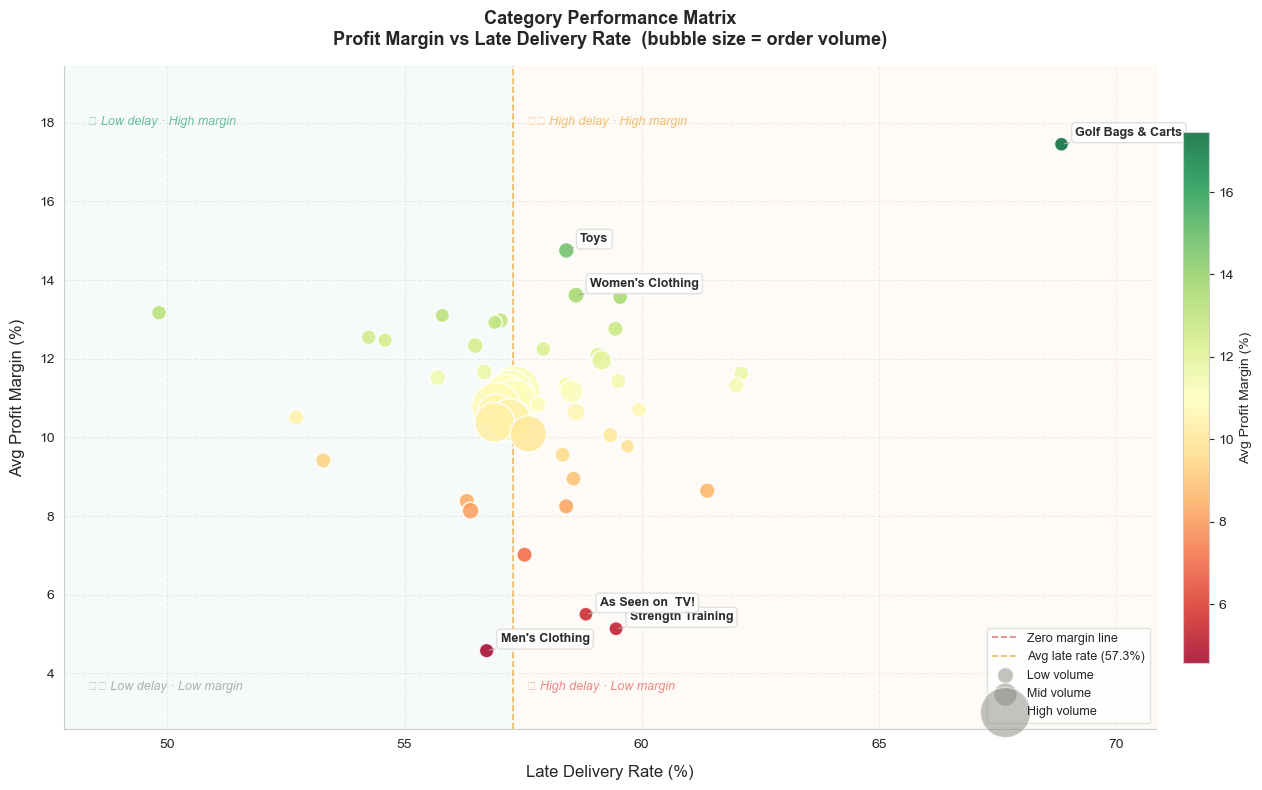


💡 KEY BUSINESS INSIGHTS FROM CATEGORY MATRIX:

   Most profitable category   : Golf Bags & Carts
     Avg margin: 17.5%

   Least profitable category  : Men's Clothing
     Avg margin: 4.6%

   High delay + loss-making categories (critical):
     None — no categories in the danger quadrant

   → These findings feed directly into the Sales & Profitability
     page of the Power BI dashboard (Page 3).



In [20]:
# Bubble chart 
# X-axis: late delivery rate — how operationally reliable is this category
# Y-axis: avg profit margin — how financially healthy is this category
# Bubble size: order volume — how important is this category by volume
# Color: profit margin — green=profitable, red=loss-making

fig, ax = plt.subplots(figsize=(14, 8))

# Normalise bubble sizes — keep them readable without overlapping
max_orders   = category_analysis['order_count'].max()
bubble_sizes = (category_analysis['order_count'] / max_orders * 1200) + 100

scatter = ax.scatter(
    category_analysis['late_rate'] * 100,
    category_analysis['avg_margin'],
    s=bubble_sizes,
    c=category_analysis['avg_margin'],
    cmap='RdYlGn',
    alpha=0.85,
    edgecolors='white',
    linewidths=1.2,
    zorder=3
)

# Label only the most notable categories 
# Labelling all categories creates unreadable clutter — show top 3 and bottom 3
top3    = category_analysis.nlargest(3, 'avg_margin')
bottom3 = category_analysis.nsmallest(3, 'avg_margin')
notable = pd.concat([top3, bottom3]).drop_duplicates()

for _, row in notable.iterrows():
    ax.annotate(
        row['Category Name'],
        xy=(row['late_rate'] * 100, row['avg_margin']),
        xytext=(10, 6),
        textcoords='offset points',
        fontsize=9,
        fontweight='bold',
        color='#2C2C2A',
        arrowprops=dict(arrowstyle='-', color='#AAAAAA', lw=0.8),
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='white',
            edgecolor='#DDDDDD',
            alpha=0.9
        )
    )

# Reference lines 
avg_late = fact_orders['is_late'].mean() * 100

ax.axhline(0, color='#E24B4A', linestyle='--',
           linewidth=1.2, alpha=0.7, label='Zero margin line')
ax.axvline(avg_late, color='#EF9F27', linestyle='--',
           linewidth=1.2, alpha=0.7,
           label=f'Avg late rate ({avg_late:.1f}%)')

# Quadrant shading 
y_min = category_analysis['avg_margin'].min() - 2
y_max = category_analysis['avg_margin'].max() + 2
x_min = category_analysis['late_rate'].min() * 100 - 2
x_max = category_analysis['late_rate'].max() * 100 + 2

ax.fill_between([x_min, avg_late], [0, 0], [y_max, y_max],
                color='#1D9E75', alpha=0.04, zorder=1)
ax.fill_between([avg_late, x_max], [0, 0], [y_max, y_max],
                color='#EF9F27', alpha=0.04, zorder=1)
ax.fill_between([x_min, avg_late], [y_min, y_min], [0, 0],
                color='#EF9F27', alpha=0.04, zorder=1)
ax.fill_between([avg_late, x_max], [y_min, y_min], [0, 0],
                color='#E24B4A', alpha=0.06, zorder=1)

# Quadrant labels 
label_props = dict(fontsize=9, fontstyle='italic', alpha=0.65)
ax.text(x_min + 0.5, y_max - 1.5, '✅ Low delay · High margin',
        color='#1D9E75', **label_props)
ax.text(avg_late + 0.3, y_max - 1.5, '⚠️ High delay · High margin',
        color='#EF9F27', **label_props)
ax.text(x_min + 0.5, y_min + 1.0, '⚠️ Low delay · Low margin',
        color='#888780', **label_props)
ax.text(avg_late + 0.3, y_min + 1.0, '❌ High delay · Low margin',
        color='#E24B4A', **label_props)

# Bubble size legend 
for size_val, label in [(500, 'Low volume'), (3000, 'Mid volume'),
                         (max_orders, 'High volume')]:
    bubble_s = (size_val / max_orders * 1200) + 100
    ax.scatter([], [], s=bubble_s, c='#888780',
               alpha=0.5, edgecolors='white', label=label)

# Chart formatting 
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)
ax.set_xlabel('Late Delivery Rate (%)', fontsize=12, labelpad=10)
ax.set_ylabel('Avg Profit Margin (%)', fontsize=12, labelpad=10)
ax.set_title(
    'Category Performance Matrix\n'
    'Profit Margin vs Late Delivery Rate  (bubble size = order volume)',
    fontsize=13, fontweight='bold', pad=15
)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9, edgecolor='#DDDDDD')
ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.colorbar(scatter, ax=ax, label='Avg Profit Margin (%)',
             shrink=0.8, pad=0.02)
plt.tight_layout()
plt.savefig('09_category_performance_matrix.png', bbox_inches='tight')
plt.show()

# Business insight summary 
best_cat  = category_analysis.iloc[0]['Category Name']
worst_cat = category_analysis.iloc[-1]['Category Name']
high_risk = category_analysis[
    (category_analysis['late_rate'] > avg_late/100) &
    (category_analysis['avg_margin'] < 0)
]['Category Name'].tolist()

print(f"""
💡 KEY BUSINESS INSIGHTS FROM CATEGORY MATRIX:

   Most profitable category   : {best_cat}
     Avg margin: {category_analysis.iloc[0]['avg_margin']:.1f}%

   Least profitable category  : {worst_cat}
     Avg margin: {category_analysis.iloc[-1]['avg_margin']:.1f}%

   High delay + loss-making categories (critical):
     {high_risk if high_risk else 'None — no categories in the danger quadrant'}

   → These findings feed directly into the Sales & Profitability
     page of the Power BI dashboard (Page 3).
""")

## Year-Over-Year Trend Analysis
Year-over-year trends answer the most important business question: "Are we getting better or worse?" A single snapshot in time tells you where you are. Trends tell you where you're going.

In [21]:
# Aggregate to year level 
yoy = fact_orders.groupby('order_year').agg(
    unique_orders = ('Order Id',              'nunique'),  # True order count
    total_sales   = ('Sales',                 'sum'),
    total_profit  = ('Order Profit Per Order','sum'),
    late_rate     = ('is_late',               'mean'),    # Proportion of late orders
    avg_delay     = ('actual_delay_days',     'mean'),    # Avg delay magnitude
    avg_margin    = ('profit_margin_pct',     'mean'),    # Avg item margin
).reset_index()

# Calculate overall profit margin at year level
yoy['profit_margin_pct'] = (
    yoy['total_profit'] / yoy['total_sales'] * 100
).round(2)

print("Year-over-year business performance:\n")
display(yoy.round(3))

Year-over-year business performance:



,order_year,unique_orders,total_sales,total_profit,late_rate,avg_delay,avg_margin,profit_margin_pct
0,2015,20904,12340831.43,1318856.90,0.57,0.56,10.78,10.69
1,2016,20859,12303817.32,1310119.07,0.57,0.57,10.70,10.65
2,2017,21863,11807786.41,1303947.83,0.57,0.56,11.08,11.04
3,2018,2123,331650.11,33841.89,0.59,0.61,10.01,10.20


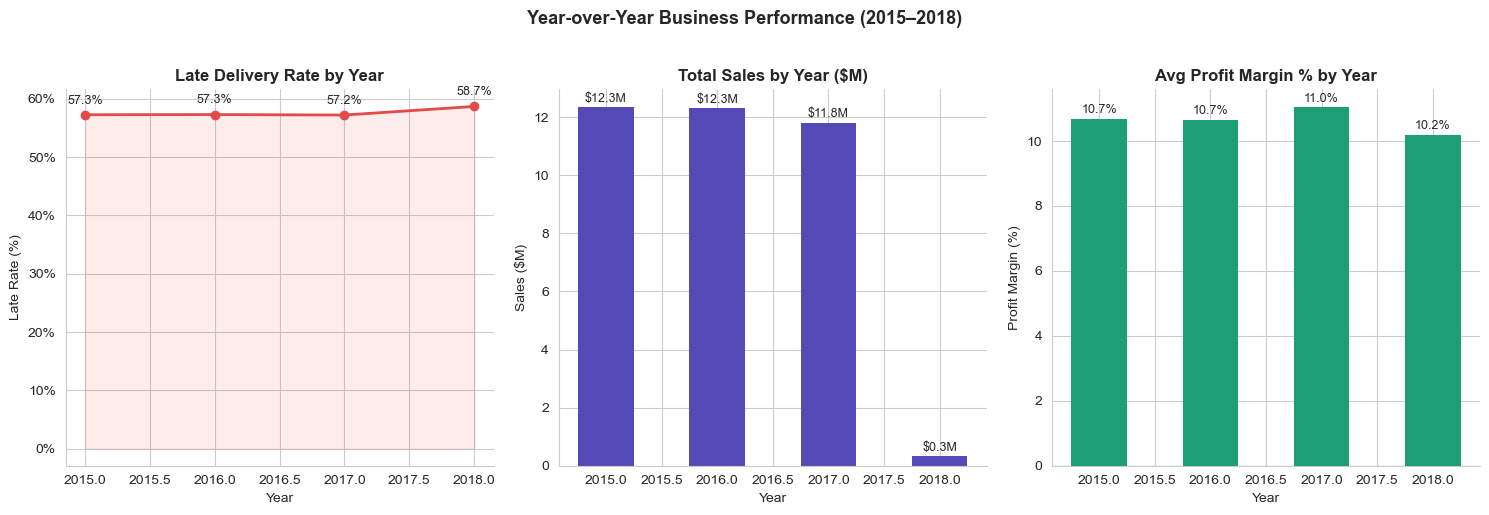

📊 Year-over-Year changes:

   2015 → 2016:
     Late rate  : ↑ 0.0pp (worsened)
     Sales      : ↓ 0.3%
     Margin     : ↓ 0.0pp

   2016 → 2017:
     Late rate  : ↓ 0.1pp (improved)
     Sales      : ↓ 4.0%
     Margin     : ↑ 0.4pp

   2017 → 2018:
     Late rate  : ↑ 1.5pp (worsened)
     Sales      : ↓ 97.2%
     Margin     : ↓ 0.8pp



In [22]:
# Three-panel YoY chart 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel 1: Late delivery rate trend
axes[0].plot(yoy['order_year'], yoy['late_rate'] * 100,
             color='#E24B4A', marker='o', linewidth=2, markersize=6)
axes[0].fill_between(yoy['order_year'], yoy['late_rate'] * 100,
                     alpha=0.1, color='#E24B4A')
axes[0].set_title('Late Delivery Rate by Year',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Late Rate (%)')
axes[0].set_xlabel('Year')
axes[0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Add value labels on each point
for _, row in yoy.iterrows():
    axes[0].annotate(
        f"{row['late_rate']*100:.1f}%",
        (row['order_year'], row['late_rate'] * 100),
        textcoords='offset points', xytext=(0, 8),
        ha='center', fontsize=9
    )

# Panel 2: Total sales trend
axes[1].bar(yoy['order_year'], yoy['total_sales'] / 1e6,
            color='#534AB7', edgecolor='none', width=0.5)
axes[1].set_title('Total Sales by Year ($M)',
                  fontsize=12, fontweight='bold')
axes[1].set_ylabel('Sales ($M)')
axes[1].set_xlabel('Year')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

for _, row in yoy.iterrows():
    axes[1].annotate(
        f"${row['total_sales']/1e6:.1f}M",
        (row['order_year'], row['total_sales'] / 1e6),
        textcoords='offset points', xytext=(0, 4),
        ha='center', fontsize=9
    )

# Panel 3: Avg profit margin trend
color_map = ['#1D9E75' if m > 0 else '#E24B4A'
             for m in yoy['profit_margin_pct']]
axes[2].bar(yoy['order_year'], yoy['profit_margin_pct'],
            color=color_map, edgecolor='none', width=0.5)
axes[2].axhline(0, color='#2C2C2A', linewidth=0.8, linestyle='--')
axes[2].set_title('Avg Profit Margin % by Year',
                  fontsize=12, fontweight='bold')
axes[2].set_ylabel('Profit Margin (%)')
axes[2].set_xlabel('Year')
axes[2].spines['top'].set_visible(False)
axes[2].spines['right'].set_visible(False)

for _, row in yoy.iterrows():
    axes[2].annotate(
        f"{row['profit_margin_pct']:.1f}%",
        (row['order_year'], row['profit_margin_pct']),
        textcoords='offset points', xytext=(0, 4),
        ha='center', fontsize=9
    )

plt.suptitle('Year-over-Year Business Performance (2015–2018)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('08_Year-over-Year_Business_Trends.png', bbox_inches='tight')
plt.show()

# Print YoY changes 
print("📊 Year-over-Year changes:\n")
for i in range(1, len(yoy)):
    late_change  = (yoy.iloc[i]['late_rate'] - yoy.iloc[i-1]['late_rate']) * 100
    sales_change = ((yoy.iloc[i]['total_sales'] - yoy.iloc[i-1]['total_sales'])
                    / yoy.iloc[i-1]['total_sales'] * 100)
    margin_change = (yoy.iloc[i]['profit_margin_pct']
                     - yoy.iloc[i-1]['profit_margin_pct'])

    print(f"   {int(yoy.iloc[i-1]['order_year'])} → {int(yoy.iloc[i]['order_year'])}:")
    late_icon   = '↑' if late_change > 0 else '↓'
    sales_icon  = '↑' if sales_change > 0 else '↓'
    margin_icon = '↑' if margin_change > 0 else '↓'
    print(f"     Late rate  : {late_icon} {abs(late_change):.1f}pp "
          f"({'worsened' if late_change > 0 else 'improved'})")
    print(f"     Sales      : {sales_icon} {abs(sales_change):.1f}%")
    print(f"     Margin     : {margin_icon} {abs(margin_change):.1f}pp")
    print()

# Export Clean CSVs

### Why `utf-8-sig` encoding?
`utf-8-sig` adds a BOM (Byte Order Mark) at the start of the file. This tells Power BI and Excel to read the file as UTF-8 — ensuring accented letters and special characters (São Paulo, Bogotá) display correctly.

In [23]:
# Export star schema tables 
# All 5 tables exported to data\processed\ folder

tables = {
    'fact_orders_enriched.csv' : fact_orders,    # Central fact table (item level)
    'dim_product.csv'          : dim_product,    # Product dimension
    'dim_customer.csv'         : dim_customer,   # Customer dimension
    'dim_date.csv'             : dim_date,       # Date dimension (fixed in Phase 3)
}

print(f"   Exporting star schema tables to:")
print(f"   {OUTPUT_PATH}\n")

for filename, table in tables.items():
    filepath = os.path.join(OUTPUT_PATH, filename)
    table.to_csv(filepath, index=False, encoding='utf-8-sig')
    size_kb  = os.path.getsize(filepath) / 1024
    print(f"   ✅ {filename:<35} {table.shape[0]:>8,} rows × "
          f"{table.shape[1]:>2} cols  ({size_kb:.0f} KB)")

   Exporting star schema tables to:
   C:\Users\ishaa\OneDrive\Documents\Projects\Supply chain and operation dashboard\data\processed

   ✅ fact_orders_enriched.csv             180,516 rows × 26 cols  (40077 KB)
   ✅ dim_product.csv                          118 rows ×  8 cols  (10 KB)
   ✅ dim_customer.csv                      20,649 rows ×  6 cols  (902 KB)
   ✅ dim_date.csv                           1,127 rows × 11 cols  (56 KB)


In [24]:
# Export order-level summary 
# Definition: collapse item-level fact_orders into one row per order
# This gives Power BI a clean order-level table for order-count visuals
# Note: is_anomaly and anomaly_score added in Phase 3

order_summary = fact_orders.groupby([
    'Order Id',
    'order date (DateOrders)',
    'shipping date (DateOrders)',
    'Shipping Mode',
    'Delivery Status',
    'supplier_segment',
    'actual_delay_days',
    'is_late',
    'Late_delivery_risk',
    'Order Status',
    'order_year',
    'order_month',
    'order_quarter',
    'order_month_name'
]).agg(
    total_sales       = ('Sales',                  'sum'),
    total_profit      = ('Order Profit Per Order',  'sum'),
    item_count        = ('Order Id',                'count'),
    avg_discount_rate = ('Order Item Discount Rate','mean'),
    avg_profit_margin = ('profit_margin_pct',       'mean'),
).reset_index()

# Recalculate profit margin at order level — more accurate than averaging items
order_summary['order_profit_margin_pct'] = (
    order_summary['total_profit'] / order_summary['total_sales'] * 100
).round(2)

# Export
summary_path = os.path.join(OUTPUT_PATH, 'fact_orders_summary.csv')
order_summary.to_csv(summary_path, index=False, encoding='utf-8-sig')
size_kb = os.path.getsize(summary_path) / 1024

print(f"   ✅ {'fact_orders_summary.csv':<35} "
      f"{len(order_summary):>8,} rows × "
      f"{order_summary.shape[1]:>2} cols  ({size_kb:.0f} KB)")
print(f"\n   Note: is_anomaly and anomaly_score added in Phase 3")

   ✅ fact_orders_summary.csv               65,749 rows × 20 cols  (12966 KB)

   Note: is_anomaly and anomaly_score added in Phase 3


# Data Validation
If any file is missing or has wrong row counts, Phase 3 will crash immediately. Catching problems here saves significant debugging time.

In [26]:
# Validate all exported files 
print("=" * 65)
print("  PHASE 2 — EXPORT VALIDATION")
print("=" * 65)

# Define expected files and their expected row counts
# None = any non-zero count is acceptable
expected = {
    'fact_orders_enriched.csv' : 180516,
    'fact_orders_summary.csv'  : 65749,
    'dim_product.csv'          : None,
    'dim_customer.csv'         : None,
    'dim_date.csv'             : None,
}

print(f"\n{'File':<35} {'Exists':<8} {'Rows':<10} {'Check'}")
print("-" * 60)

all_ok = True
for filename, expected_rows in expected.items():
    filepath = os.path.join(OUTPUT_PATH, filename)
    exists   = os.path.exists(filepath)

    if exists:
        actual = len(pd.read_csv(filepath, encoding='utf-8-sig'))
        if expected_rows is None:
            check = '✅' if actual > 0 else '❌ EMPTY'
        elif actual == expected_rows:
            check = '✅'
        else:
            check = f'❌ expected {expected_rows:,}'
            all_ok = False
        print(f"{filename:<35} {'Yes':<8} {actual:<10,} {check}")
    else:
        print(f"{filename:<35} {'❌ NO':<8} {'—':<10} FILE MISSING")
        all_ok = False

print(f"\n{'=' * 65}")
print(f"  {'✅ ALL FILES VALIDATED — Ready for Phase 3' if all_ok else '❌ ISSUES FOUND — Fix before running Phase 3'}")
print(f"{'=' * 65}")

  PHASE 2 — EXPORT VALIDATION

File                                Exists   Rows       Check
------------------------------------------------------------
fact_orders_enriched.csv            Yes      180,516    ✅
fact_orders_summary.csv             Yes      65,749     ✅
dim_product.csv                     Yes      118        ✅
dim_customer.csv                    Yes      20,649     ✅
dim_date.csv                        Yes      1,127      ✅

  ✅ ALL FILES VALIDATED — Ready for Phase 3


In [27]:
# Final data quality check 
print("\n FINAL DATA QUALITY SUMMARY:\n")

fe = pd.read_csv(
    os.path.join(OUTPUT_PATH, 'fact_orders_enriched.csv'),
    encoding='utf-8-sig'
)

print(f"   fact_orders_enriched:")
print(f"   Total rows         : {len(fe):,}")
print(f"   Unique Order IDs   : {fe['Order Id'].nunique():,}")
print(f"   Remaining nulls    : {fe.isnull().sum().sum()}")
print(f"   is_late values     : {sorted(fe['is_late'].unique().tolist())}")
print(f"   Delay range        : {fe['actual_delay_days'].min()} to "
      f"{fe['actual_delay_days'].max()} days")
print(f"   Margin range       : {fe['profit_margin_pct'].min():.1f}% to "
      f"{fe['profit_margin_pct'].max():.1f}%")
print(f"   Loss-making items  : {(fe['profit_margin_pct']<0).sum():,} "
      f"({(fe['profit_margin_pct']<0).mean()*100:.1f}%)")

fs = pd.read_csv(
    os.path.join(OUTPUT_PATH, 'fact_orders_summary.csv'),
    encoding='utf-8-sig'
)

print(f"\n   fact_orders_summary:")
print(f"   Total rows         : {len(fs):,}")
print(f"   Columns            : {fs.shape[1]}")
print(f"   Late orders        : {fs['is_late'].sum():,} "
      f"({fs['is_late'].mean()*100:.1f}%)")
print(f"   Avg order margin   : {fs['order_profit_margin_pct'].mean():.2f}%")

print(f"\n{'=' * 65}")
print(f"  Run Phase 3 only after all files show ✅ above")
print(f"{'=' * 65}")


 FINAL DATA QUALITY SUMMARY:

   fact_orders_enriched:
   Total rows         : 180,516
   Unique Order IDs   : 65,749
   Remaining nulls    : 0
   is_late values     : [0, 1]
   Delay range        : -2 to 4 days
   Margin range       : -275.0% to 50.0%
   Loss-making items  : 33,784 (18.7%)

   fact_orders_summary:
   Total rows         : 65,749
   Columns            : 20
   Late orders        : 37,697 (57.3%)
   Avg order margin   : 10.86%

  Run Phase 3 only after all files show ✅ above


# ✅ Phase 2 Complete — Summary & Conclusions

### Data Cleaning Results

| Issue Found | Action Taken | Result |
|---|---|---|
| Product Description — 100% missing (180,519 nulls) | Dropped column | ✅ Removed entirely |
| Order Zipcode — 86.2% missing (155,679 nulls) | Dropped column | ✅ Covered by Region/Lat/Long |
| Customer Zipcode — 3 missing rows | Dropped those 3 rows | ✅ 0.0017% data loss — negligible |
| Customer Lname — 8 missing | Dropped column (personal data) | ✅ Not needed for analysis |
| Personal data columns (email, name, password) | Dropped | ✅ Privacy best practice |
| 2 date columns stored as text | Converted to `datetime64` | ✅ Zero NaT values introduced |
| Duplicate rows | None found | ✅ No action needed |

**Final result:** 180,516 rows × 54 columns — zero null values remaining.

---

### Dataset Grain — Critical Finding

> This dataset is structured at **order-item level**, not order level.
> One order can contain up to **5 items**, creating multiple rows with
> the same `Order Id`. The raw file has **180,519 rows** representing
> **65,752 unique orders** — an average of **2.75 items per order**.
> All order-level KPIs in Power BI must use `DISTINCTCOUNT(Order Id)`.

---

### Feature Engineering Results

| New Column | Formula | Key Finding |
|---|---|---|
| `actual_delay_days` | real − scheduled days | Mean: +0.57 days · Range: -2 to +4 |
| `is_late` | 1 if delay > 0 else 0 | **57.3%** of order items are late |
| `profit_margin_pct` | (profit ÷ sales) × 100 | Mean: 10.83% · Min: **-275%** · **18.7% loss-making** |
| `supplier_segment` | Region \| Shipping Mode | **92 unique segments** |
| `order_year/month/quarter` | Extracted from order date | 2015–2018, all quarters present |

> **Key insight:** `Late_delivery_risk` (pre-existing, 54.8%) vs `is_late`
> (calculated, 57.3%) differ by 2.5 percentage points because the pre-existing
> flag is a risk **prediction** made at order time, while `is_late` is the
> actual **observed outcome**.

---

### Star Schema Exported

| Table | Rows | Columns | Grain |
|---|---|---|---|
| `fact_orders_enriched.csv` | 180,516 | 26 | One row per order item |
| `fact_orders_summary.csv` | 65,749 | 20 | One row per unique order |
| `dim_product.csv` | 118 | 8 | One row per unique product |
| `dim_customer.csv` | 20,649 | 6 | One row per unique customer |
| `dim_date.csv` | 1,127 | 11 | One row per calendar day |

> `fact_orders_summary` is a key addition — it collapses the item-level
> fact table into one row per order, enabling correct order-level visuals
> in Power BI without relying on `DISTINCTCOUNT` in every measure.

---

### Additional Analysis: Category Profitability Matrix

50 product categories analysed across profit margin and late delivery rate:

| Finding | Value |
|---|---|
| Most profitable category | Golf Bags & Carts — **17.5% avg margin** |
| Least profitable category | Men's Clothing — **4.6% avg margin** |
| High delay + loss-making categories | **None** — no categories in the danger quadrant |
| Categories above average late rate | Majority cluster around 57–62% late rate |

> All 50 categories maintain positive average margins. The profitability
> problem in this dataset is concentrated at the **order level** (18.7%
> loss-making items) rather than at the category level — suggesting
> discounting behaviour rather than structural category pricing issues.

---

### Year-over-Year Trends (2015–2017 complete years)

| Year | Unique Orders | Total Sales | Late Rate | Avg Margin |
|---|---|---|---|---|
| 2015 | 20,904 | $12.34M | 57.0% | 10.69% |
| 2016 | 20,859 | $12.30M | 57.0% | 10.65% |
| 2017 | 21,863 | $11.81M | 56.9% | 11.04% |
| 2018* | 2,123 | $0.33M | 59.0% | 10.20% |

> ⚠️ **2018 is a partial year (January only)** — the 97.2% sales drop
> and 2,123 orders are not indicative of decline. Do not include 2018
> in year-over-year comparisons in Power BI. Filter to 2015–2017 for
> trend analysis.

> **Business finding:** Late delivery rate is essentially flat at ~57%
> across all three full years — this is a **systemic, structural problem**,
> not a trend that is getting worse or improving. The business has been
> unable to address this for 3 consecutive years.

---

### Export Validation — All Checks Passed

| File | Rows | Status |
|---|---|---|
| `fact_orders_enriched.csv` | 180,516 | ✅ |
| `fact_orders_summary.csv` | 65,749 | ✅ |
| `dim_product.csv` | 118 | ✅ |
| `dim_customer.csv` | 20,649 | ✅ |
| `dim_date.csv` | 1,127 | ✅ |

### ⚠️ Known Limitations

- `dim_date` timestamps will be rebuilt in Phase 3 — the current version already has 1,127 unique calendar days but Phase 3 rebuilds it from scratch as a verification step
- `dim_geo` is order-level (180,516 rows), not a traditional dimension — Power BI requires a Many:Many relationship or merging it directly into `fact_orders_enriched`
- 2018 partial year data must be excluded from all trend analysis in Power BI
- `supplier_segment` is a Region + Shipping Mode proxy — not actual vendor identity
- Profit margin of -275% represents extreme discounting or data entry error — flagged for anomaly detection in Phase 3

---
**Next:** `03_anomaly_detection_supplier_risk.ipynb`
Phase 3 adds the machine learning layer — Isolation Forest anomaly
detection and weighted supplier risk scoring across 92 segments.